In [ ]:
!sudo apt install git-lfs
!git clone https://github.com/google-research/scenic.git
%cd scenic
!pip install -e .
!pip install flax jax jaxlib tensorflow tensorflow_datasets

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
git-lfs is already the newest version (3.0.2-1ubuntu0.3).
0 upgraded, 0 newly installed, 0 to remove and 34 not upgraded.
Cloning into 'scenic'...
remote: Enumerating objects: 9322, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 9322 (delta 6), reused 4 (delta 4), pack-reused 9309 (from 2)
Receiving objects: 100% (9322/9322), 65.22 MiB | 35.75 MiB/s, done.
Resolving deltas: 100% (6453/6453), done.
/content/scenic
Obtaining file:///content/scenic
  Preparing metadata (setup.py) ... done
  Cloning https://github.com/google-deepmind/optax.git (to revision main) to /tmp/pip-install-hup3qy5m/optax_670c4873d23d4a6fbf66d09970776138
  Running command git clone --filter=blob:none --quiet https://github.com/google-deepmind/optax.git /tmp/pip-install-hup3qy5m/optax_670c4873d23d4a6fbf66d09970776138
  Resolved https://github.com/google-de

In [ ]:
!gsutil -m cp -r gs://scenic-checkpoints/pali/pali3_ckpt_dir .

BucketNotFoundException: 404 gs://scenic-checkpoints bucket does not exist.
CommandException: 1 file/object could not be transferred.


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving abhi.jpg to abhi (1).jpg


In [ ]:
from transformers import AutoProcessor, GitForCausalLM
from PIL import Image
import torch
from torchvision import transforms
from torchvision.models import resnet50

# Load model and processor
model = GitForCausalLM.from_pretrained("microsoft/git-large")
processor = AutoProcessor.from_pretrained("microsoft/git-large")
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

# Load and preprocess image
image = Image.open("abhi.jpg").convert("RGB")  # Make sure the image file exists
inputs = processor(images=image, return_tensors="pt").to(device)

# Transform image for ResNet
transform = transforms.Compose([
    transforms.ToTensor()
])

input_tensor = transform(image).unsqueeze(0).to(device).to(torch.float32)
input_tensor.requires_grad = True

# Load ResNet (used for later adversarial work)
resnet = resnet50(pretrained=True).to(device)
resnet.eval()

# Caption generation function
def generate_caption(img):
    img_tensor = processor(images=img, return_tensors="pt").to(device)
    outputs = model.generate(**img_tensor, max_length=50)
    return processor.batch_decode(outputs, skip_special_tokens=True)[0].strip()

# Generate and print original caption
original_caption = generate_caption(image)

print("\n🔹 Original Image Caption:")
print(original_caption)


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



🔹 Original Image Caption:
the letters are white



⚠️ Adversarial Image Caption (FGSM Attack):
a man poses with a giant heart


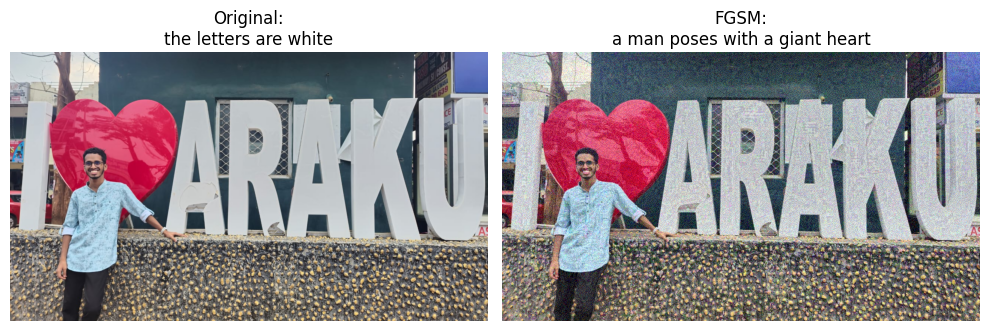

In [ ]:
import torch.nn as nn

# Use cross-entropy loss on ResNet to guide the attack
criterion = nn.CrossEntropyLoss()

# Predict label with ResNet (used as target for FGSM)
with torch.no_grad():
    output = resnet(input_tensor)
    pred_label = output.argmax(dim=1)

# FGSM attack
epsilon = 0.09  # Small perturbation scale
input_tensor.requires_grad = True

output = resnet(input_tensor)
loss = criterion(output, pred_label)
resnet.zero_grad()
loss.backward()

# Generate adversarial image
perturbed_tensor = input_tensor + epsilon * input_tensor.grad.sign()
perturbed_tensor = torch.clamp(perturbed_tensor, 0, 1)

# Convert back to PIL Image for captioning
perturbed_image = transforms.ToPILImage()(perturbed_tensor.squeeze().cpu())

# Get caption for adversarial image
adv_caption = generate_caption(perturbed_image)

# Show results
print("\n⚠️ Adversarial Image Caption (FGSM Attack):")
print(adv_caption)

# Display results
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Original:\n" + original_caption)
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(perturbed_image)
plt.title("FGSM:\n" + adv_caption)
plt.axis('off')

plt.tight_layout()
plt.show()


🔥 PGD Adversarial Image Caption:
a man poses with a giant heart shaped sign in front of a building in the philippines.


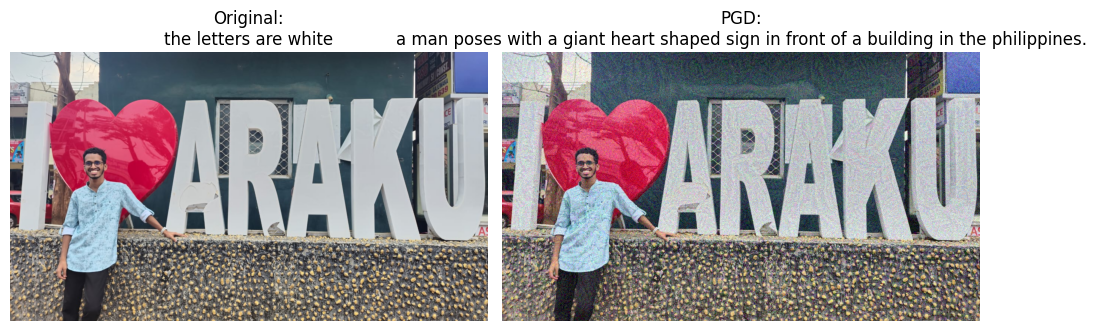

In [ ]:
def pgd_attack(model, images, labels, eps=0.1, alpha=0.08, iters=10):
    images = images.clone().detach().to(device)
    labels = labels.to(device)
    ori_images = images.clone().detach()

    for i in range(iters):
        images.requires_grad = True
        outputs = model(images)
        model.zero_grad()
        loss = criterion(outputs, labels)
        loss.backward()

        # Perform PGD step
        adv_images = images + alpha * images.grad.sign()

        # Project the perturbation
        eta = torch.clamp(adv_images - ori_images, min=-eps, max=eps)
        images = torch.clamp(ori_images + eta, min=0, max=1).detach()

    return images

# Run PGD attack
pgd_tensor = pgd_attack(resnet, input_tensor, pred_label, eps=0.1, alpha=0.08, iters=10)

# Convert PGD adversarial image to PIL for captioning
pgd_image = transforms.ToPILImage()(pgd_tensor.squeeze().cpu())

# Generate caption for PGD image
pgd_caption = generate_caption(pgd_image)

# Print result
print("\n🔥 PGD Adversarial Image Caption:")
print(pgd_caption)

# Display results
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Original:\n" + original_caption)
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(pgd_image)
plt.title("PGD:\n" + pgd_caption)
plt.axis('off')

plt.tight_layout()
plt.show()


🧩 Adversarial Patch Caption:
a large white sign with a red heart


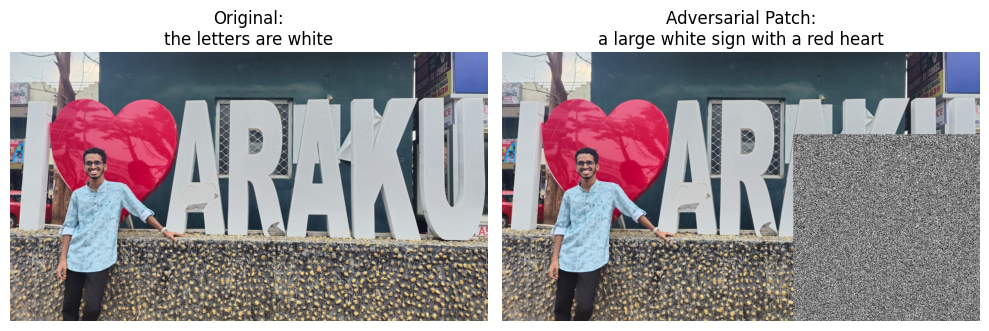

In [ ]:
import torchvision.transforms.functional as TF

def apply_adversarial_patch(image, patch_size=500, position='bottom-right', patch_strength=1.0):
    """
    Applies a random adversarial-looking patch to an image.
    This is a simulated patch, not trained — used for visual attack.
    """
    img = image.copy()
    width, height = img.size

    # Create random noise patch
    patch = Image.effect_noise((patch_size, patch_size), 100).convert("RGB")
    patch = TF.adjust_brightness(patch, patch_strength)

    # Positioning
    if position == 'top-left':
        x, y = 0, 0
    elif position == 'top-right':
        x, y = width - patch_size, 0
    elif position == 'bottom-left':
        x, y = 0, height - patch_size
    else:  # 'bottom-right'
        x, y = width - patch_size, height - patch_size

    img.paste(patch, (x, y))
    return img
# Apply patch to original image
patched_image = apply_adversarial_patch(image, patch_size=500, position='bottom-right', patch_strength=1.0)

# Generate caption
patched1_caption = generate_caption(patched_image)

print("\n🧩 Adversarial Patch Caption:")
print(patched1_caption)

# Display results
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Original:\n" + original_caption)
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(patched_image)
plt.title("Adversarial Patch:\n" + patched1_caption)
plt.axis('off')

plt.tight_layout()
plt.show()

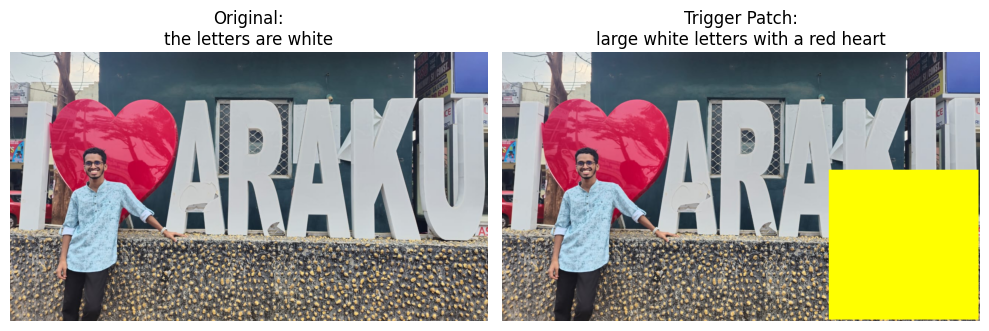

In [ ]:
from PIL import ImageDraw
import matplotlib.pyplot as plt

# --- Add trigger patch ---
def add_trigger_patch(img, color=(255, 255, 0), size=400, position="bottom_right"):
    img = img.copy()
    draw = ImageDraw.Draw(img)
    w, h = img.size

    if position == "bottom_right":
        x0, y0 = w - size - 5, h - size - 5
    elif position == "top_left":
        x0, y0 = 5, 5
    else:
        x0, y0 = w//2 - size//2, h//2 - size//2

    draw.rectangle([x0, y0, x0+size, y0+size], fill=color)
    return img

# Apply trigger patch
patched_image = add_trigger_patch(image, color=(255, 255, 0), size=400)

# Generate captions
original_caption = generate_caption(image)
patched_caption = generate_caption(patched_image)

# Display results
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Original:\n" + original_caption)
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(patched_image)
plt.title("Trigger Patch:\n" + patched_caption)
plt.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
!pip install foolbox


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 32.3 MB/s eta 0:00:00


In [ ]:
import foolbox as fb
import torchvision.transforms as T
from torchvision.models import resnet50
import torch.nn.functional as F

# Prepare classifier for UAP training
classifier_model = resnet50(pretrained=True).eval().to(device)
fmodel = fb.PyTorchModel(classifier_model, bounds=(0, 1))

# Load multiple natural images for universal patch training
from torchvision.datasets import CIFAR10
from torch.utils.data import DataLoader

transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor()
])

cifar = CIFAR10(root="./data", train=True, download=True, transform=transform)
dataloader = DataLoader(cifar, batch_size=8, shuffle=True)

# Initialize patch
patch_size = (50, 50)  # small patch size
universal_patch = torch.rand(3, *patch_size, requires_grad=True, device=device)

optimizer = torch.optim.Adam([universal_patch], lr=0.1)

# Training loop for universal patch
for i, (imgs, labels) in enumerate(dataloader):
    if i > 100: break  # keep it short for demo
    imgs, labels = imgs.to(device), labels.to(device)

    # Overlay patch on each image (e.g., top-left corner)
    patched_imgs = imgs.clone()
    patched_imgs[:, :, :patch_size[0], :patch_size[1]] = universal_patch.unsqueeze(0)

    outputs = classifier_model(patched_imgs)
    loss = -F.cross_entropy(outputs, labels)  # Negative to fool classifier

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if i % 10 == 0:
        print(f"Step {i}, Loss: {loss.item():.4f}")



/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 170M/170M [00:03<00:00, 47.9MB/s]


Step 0, Loss: -11.0403
Step 10, Loss: -16.7508
Step 20, Loss: -28.3865
Step 30, Loss: -33.4041
Step 40, Loss: -39.3122
Step 50, Loss: -42.1716
Step 60, Loss: -44.6958
Step 70, Loss: -46.3309
Step 80, Loss: -48.7996
Step 90, Loss: -52.1612
Step 100, Loss: -54.5093



⚠️ Caption with Adversarial Patch:
the letters are white


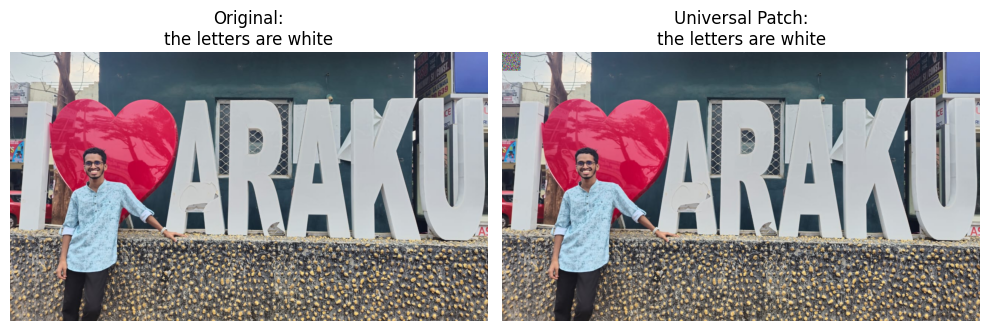

In [ ]:
def apply_patch(img, patch):
    img_tensor = T.ToTensor()(img).to(device)
    img_tensor[:, :patch_size[0], :patch_size[1]] = patch.detach()
    return T.ToPILImage()(img_tensor.cpu())

patched_image = apply_patch(image, universal_patch)

unipatch_caption = generate_caption(patched_image)

print("\n⚠️ Caption with Adversarial Patch:")
print(unipatch_caption)

# Display results
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Original:\n" + original_caption)
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(patched_image)
plt.title("Universal Patch:\n" + unipatch_caption)
plt.axis('off')

plt.tight_layout()
plt.show()
